In [3]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.offline as pyo

pyo.init_notebook_mode(connected = True)
pd.options.plotting.backend = 'plotly'

In [5]:
portfolio = ['HDFCBANK.NS', 'TCS.NS', 'RELIANCE.NS', 'GC=F', '^NSEI']
portfolio

['HDFCBANK.NS', 'TCS.NS', 'RELIANCE.NS', 'GC=F', '^NSEI']

In [7]:
df = yf.download(portfolio, start='2015-01-01', end='2026-01-30')['Close']
df

[*********************100%***********************]  5 of 5 completed


Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-01,NaN,217.235367,189.999802,988.879517,NaN
2015-01-02,1186.000000,220.258682,189.496918,1002.048889,8395.450195
2015-01-05,1203.900024,218.399063,187.421280,986.820679,8378.400391
2015-01-06,1219.300049,214.999222,178.915237,950.440430,8127.350098
2015-01-07,1210.599976,215.626709,182.809784,939.213562,8102.100098
...,...,...,...,...,...
2026-01-23,4976.200195,916.099976,1386.099976,3162.500000,25048.650391
2026-01-26,5079.700195,NaN,NaN,NaN,NaN
2026-01-27,5079.899902,926.400024,1380.500000,3158.000000,25175.400391


In [11]:
log_returns = np.log(df/df.shift(1)).dropna()
log_returns

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-05,0.014980,-0.008479,-0.011014,-0.015314,-0.002033
2015-01-06,0.012711,-0.015690,-0.046447,-0.037563,-0.030422
2015-01-07,-0.007161,0.002914,0.021534,-0.011883,-0.003112
2015-01-08,-0.001819,0.020788,-0.014443,0.010737,0.016221
2015-01-09,0.006270,0.011131,0.021442,0.027645,0.006042
...,...,...,...,...,...
2026-01-21,0.015055,-0.011720,0.007575,0.006522,-0.002977
2026-01-22,0.015810,-0.001794,-0.001496,0.008863,0.005249
2026-01-23,0.013637,-0.002834,-0.011762,0.003833,-0.009585


In [27]:
monthly_returns = log_returns.resample('ME').sum()
monthly_returns

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Date,,,,,
2015-01-31,0.062340,0.060909,-0.007062,-0.025274,0.018503
2015-02-28,-0.030828,-0.030321,-0.050027,0.032666,-0.003152
2015-03-31,0.000348,-0.005799,-0.017709,-0.022984,-0.020341
2015-04-30,-0.008161,-0.023603,0.050474,-0.010045,-0.031157
2015-05-31,0.016489,0.045342,0.018267,0.054045,0.026372
...,...,...,...,...,...
2025-09-30,0.078902,0.006858,-0.001831,-0.074402,0.001281
2025-10-31,0.023516,0.036472,0.101347,0.043135,0.040941
2025-11-30,0.036806,0.017283,0.039162,0.026829,0.022053


In [29]:
monthly_returns.cov()

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Ticker,,,,,
GC=F,0.001535,-0.000251,-0.000257,-0.000050,-0.000103
HDFCBANK.NS,-0.000251,0.003248,0.001711,0.000674,0.001899
RELIANCE.NS,-0.000257,0.001711,0.004445,0.001517,0.001823
TCS.NS,-0.000050,0.000674,0.001517,0.003446,0.001262
^NSEI,-0.000103,0.001899,0.001823,0.001262,0.001803


The covariance and variance of the stock in diagonal gonna be same

In [31]:
monthly_returns.var()

Ticker
GC=F           0.001535
HDFCBANK.NS    0.003248
RELIANCE.NS    0.004445
TCS.NS         0.003446
^NSEI          0.001803
dtype: float64

In [33]:
monthly_returns.corr()

Ticker,GC=F,HDFCBANK.NS,RELIANCE.NS,TCS.NS,^NSEI
Ticker,,,,,
GC=F,1.000000,-0.112484,-0.098559,-0.021636,-0.061923
HDFCBANK.NS,-0.112484,1.000000,0.450237,0.201446,0.784781
RELIANCE.NS,-0.098559,0.450237,1.000000,0.387583,0.643987
TCS.NS,-0.021636,0.201446,0.387583,1.000000,0.506053
^NSEI,-0.061923,0.784781,0.643987,0.506053,1.000000


<Axes: xlabel='Ticker', ylabel='Ticker'>

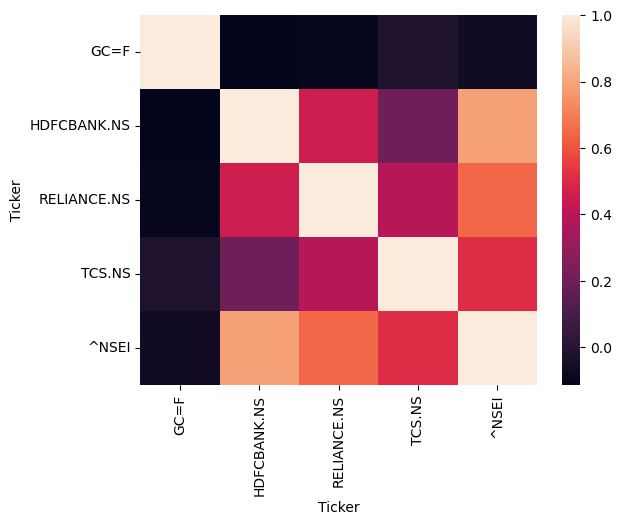

In [35]:
sns.heatmap(monthly_returns.corr())

We don't want our stock to be perfectly correlated. If they are perfectly correlated then it will not provide dowside protection from uncertainity